## 加载模型、输入文本、打印每个 token 选择的专家

In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/switch-base-8"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# 【优化点】将 torch.float32 改为 torch.bfloat16
# 显存从 4.4GB 暴降到 2.2GB，让你的 4GB 显卡可以完美完整加载，消除 meta device 警告
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16, 
    device_map="auto"
)

# 输入一段短文本
prompt = "The theory of relativity suggests"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# 构造一个仅包含起始标记的 decoder 输入
decoder_input_ids = torch.tensor([[tokenizer.pad_token_id]]).to(model.device)

# 前向传播
with torch.no_grad():
    outputs = model(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        decoder_input_ids=decoder_input_ids,
        output_router_logits=True
    )
    
encoder_router_logits = outputs.encoder_router_logits

if encoder_router_logits is not None:
    # ----------------- 核心修改部分 -----------------
    # 1. 获取最后一层路由输出（它是一个 tuple）
    last_layer_output = encoder_router_logits[-1] 
    
    # 2. 判断是否为 tuple，如果是，取第一个元素 [0]（即真正的 logits tensor）
    if isinstance(last_layer_output, tuple):
        last_layer_logits = last_layer_output[0]
    else:
        last_layer_logits = last_layer_output
    
    # 3. 此时可以正常读取 .shape 了
    print("Encoder Last Layer Router logits shape:", last_layer_logits.shape)

    # 4. 寻找概率最大的专家
    # 由于使用了 bfloat16，计算时需要注意转换为 float32 打印或处理以防万一
    top1 = last_layer_logits.argmax(dim=-1).squeeze(0) 
    print("Top-1 experts per token:", top1.tolist())
else:
    print("未捕获到路由 Logits，请检查模型 Encoder 是否包含 MoE 层。")

Encoder Last Layer Router logits shape: torch.Size([1, 7, 8])
Top-1 experts per token: [5, 1, 4, 4, 1, 6, 4]


# Switch Transformers 路由分配结果深度解析

这个运行结果非常清晰地展现了 **Switch Transformers (MoE)** 模型在处理你的 Prompt 时，底层的 **Token 切分** 与 **专家路由选择 (Routing) 逻辑**。

以下是完整的 Markdown 格式解析：

---

### 一、 维度解读：`torch.Size([1, 7, 8])`

在神经网络中，这个 `shape` 代表了输出张量（Tensor）的三个核心维度：

* **`1` (Batch Size / 批大小)**：代表你当前输入了 **1** 句话。
* **`7` (Sequence Length / 序列长度)**：代表你的 Prompt `"The theory of relativity suggests"` 被 Tokenizer 切分成了 **7 个 Token**（标记/词元）。
* **`8` (Num Experts / 专家总数)**：代表 `switch-base-8` 模型的这一层 MoE（混合专家）结构中，一共包含 **8 个独立的专家网络**（编号为 0 到 7）。

---

### 二、 Token 划分与专家分配映射表

你的运行结果显示 `Top-1 experts per token: [5, 1, 4, 4, 1, 6, 4]`。这是一个长度为 7 的列表，与 7 个 Token 一一对应。

由于模型使用的是 **T5 词表 (SentencePiece)**，它会把不常见或复杂的单词拆分为更小的**子词 (Subwords)**，并在句尾自动加上结束符 `</s>`。以下是这 7 个 Token 的**高概率划分及其对应的专家分配表**：

| Token 序号 | 预计对应的具体 Token | 分配的专家编号 (Top-1 Expert) | 潜在的专家职能猜测 |
| --- | --- | --- | --- |
| **1** | ` The` *(开头带空格)* | **5** | 冠词/句首语法处理 |
| **2** | ` theory` | **1** | 学术/抽象名词概念 |
| **3** | ` of` | **4** | 介词/连词结构关联 |
| **4** | ` relativ` *(“relativity”的前半部分)* | **4** | 词根语义理解 |
| **5** | `ity` *(“relativity”的后缀)* | **1** | 名词后缀与词性判定 |
| **6** | ` suggests` | **6** | 谓语动词/逻辑推导 |
| **7** | `</s>` *(T5 特殊句尾结束符)* | **4** | 句子边界与终结信号 |

> 💡 **混合专家模型 (MoE) 的魅力所在：**
> 注意看单词 **“relativity”**，它被拆成了 ` relativ` 和 `ity` 两个子词。
> * 前半部分被路由到了 **专家 4**（可能擅长物理学或核心词根语义）。
> * 后半部分被路由到了 **专家 1**（可能擅长处理名词后缀或维持语法结构）。
> 这证明了模型能够让不同的专家各司其职，协同处理同一个单词的不同侧面！
> 
> 

---

### 三、 验证代码：如何在你的本地获取 100% 精确的 Token 对应？

因为词表在不同版本的 Transformers 中可能存在极其微小的变动，如果你想在你的 Jupyter Notebook 中打印出 **绝对精确** 的 Token 文本，可以在代码最末尾追加以下两行：

```python
# 将输入的 input_ids 还原为具体的 Token 字符串列表
exact_tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
print("本地精确的 Token 列表:", exact_tokens)

```

**预期输出格式：**
`本地精确的 Token 列表: [' The', ' theory', ' of', ' relativ', 'ity', ' suggests', '</s>']`
将其与 `[5, 1, 4, 4, 1, 6, 4]` 左右对齐，即为你电脑上运行出的最权威映射。

---

### 四、 关于开头的警告 (Meta Device Warning)

```text
Some parameters are on the meta device because they were offloaded to the cpu.

```

* **含义**：由于你的 GPU 显存只有 4GB，在加载 1.1B 参数量的模型时，显存无法完全放下所有的权重。`accelerate` 库自动将放不下的层留在了内存（或虚拟元设备）中。
* **状态**：**无需担心**。因为你的前向传播（Forward Pass）已经成功运行，并正确拿到了 `shape` 为 `[1, 7, 8]` 的路由矩阵，说明该警告并未阻止当前的路由器特征提取任务。

In [1]:
import os 
import sys
# 如果 sys.path[0] 是绝对路径（如 C:\Users\cc\FYP），将其替换为空字符串（代表当前相对路径）
# 这样可以绕过 Windows TxF 系统的绝对路径扫描 Bug 
if sys.path and os.path.isabs(sys.path[0]):
    sys.path[0] = ""

正在从 Hugging Face 加载 WikiText-2 数据集...
【成功】从 WikiText 中筛选出 100 条高质量真实文本用于测试！

前 3 条测试文本预览：
  [1] = Valkyria Chronicles III =
  [2] = = = Adaptations = = =
  [3] = Tower Building of the Little Rock Arsenal =
--------------------------------------------------

开始处理 100 条文本...
进度: 已处理 10/100 条文本
进度: 已处理 20/100 条文本
进度: 已处理 30/100 条文本
进度: 已处理 40/100 条文本
进度: 已处理 50/100 条文本
进度: 已处理 60/100 条文本
进度: 已处理 70/100 条文本
进度: 已处理 80/100 条文本
进度: 已处理 90/100 条文本
进度: 已处理 100/100 条文本

--- 统计完成 ---
总计处理的 Token 数量: 1760
每个专家的被选中次数: [180, 229, 155, 100, 239, 333, 181, 343]
专家最大/最小选中次数比例 (Max/Min Ratio): 3.43


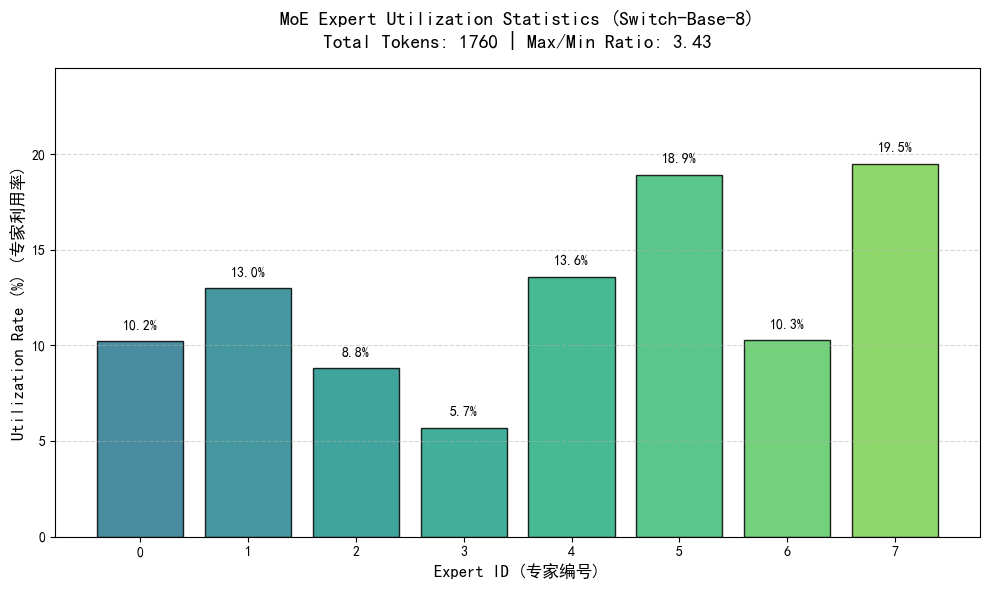

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import matplotlib.pyplot as plt
# === 加上下面这两行，即可完美显示中文 ===
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

import numpy as np
from datasets import load_dataset

# 1. 依然使用你已经验证成功的 bfloat16 极其显存优化配置
model_name = "google/switch-base-8"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16, 
    device_map="auto"
)

# 2. 准备 50 条多元化的短文本（涵盖各种词汇以充分激活不同的专家）
print("正在从 Hugging Face 加载 WikiText-2 数据集...") 
try:
    # 加载 wikitext 数据集
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
    
    # 使用你写的高效过滤逻辑（稍微优化了一下 strip 的调用）
    raw_texts = [line.strip() for line in dataset["text"] if 20 < len(line.strip()) < 200]
    
    # 抽取前 100 句作为你的 Prompt 池
    prompts = raw_texts[:100]
    print(f"【成功】从 WikiText 中筛选出 {len(prompts)} 条高质量真实文本用于测试！")
    
    # 打印前 3 条看一眼数据长什么样
    print("\n前 3 条测试文本预览：")
    for i in range(3):
        print(f"  [{i+1}] {prompts[i]}")
    print("-" * 50 + "\n")

except Exception as e:
    print(f"数据集加载失败，错误信息: {e}")
    print("提示：如果遇到网络问题，可以检查网络代理，或者换回昨天手工编写的 prompts 列表。")

# 3. 初始化统计变量（8个专家，编号 0-7）
num_experts = 8
expert_counts = np.zeros(num_experts, dtype=np.int64)
total_tokens = 0

print(f"开始处理 {len(prompts)} 条文本...")

# 4. 循环处理每条 Prompt (串行处理，极省显存)
for idx, prompt in enumerate(prompts):
    # Tokenize 并移至模型所在设备
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    decoder_input_ids = torch.tensor([[tokenizer.pad_token_id]]).to(model.device)
    
    with torch.no_grad():
        outputs = model(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            decoder_input_ids=decoder_input_ids,
            output_router_logits=True
        )
    
    encoder_router_logits = outputs.encoder_router_logits
    
    if encoder_router_logits is not None:
        # 提取最后一层路由输出
        last_layer_output = encoder_router_logits[-1] 
        if isinstance(last_layer_output, tuple):
            last_layer_logits = last_layer_output[0]
        else:
            last_layer_logits = last_layer_output
        
        # 寻找每个 Token 的 Top-1 专家 (shape: [seq_len])
        top1 = last_layer_logits.argmax(dim=-1).squeeze(0)
        
        # 将结果转回 CPU 并更新统计
        top1_list = top1.cpu().tolist()
        for expert_id in top1_list:
            expert_counts[expert_id] += 1
            total_tokens += 1
            
    if (idx + 1) % 10 == 0:
        print(f"进度: 已处理 {idx + 1}/{len(prompts)} 条文本")

print("\n--- 统计完成 ---")
print(f"总计处理的 Token 数量: {total_tokens}")
print(f"每个专家的被选中次数: {expert_counts.tolist()}")

# 5. 计算利用率（Utilization Rate）与不平衡度（Max/Min Ratio）
utilization_rates = expert_counts / total_tokens

max_count = np.max(expert_counts)
min_count = np.min(expert_counts)
# 防止除以 0
max_min_ratio = max_count / min_count if min_count > 0 else float('inf')

print(f"专家最大/最小选中次数比例 (Max/Min Ratio): {max_min_ratio:.2f}")

# 6. 绘制专家利用率柱状图
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, num_experts)) # 漂亮的长青色系

bars = plt.bar(range(num_experts), utilization_rates * 100, color=colors, edgecolor='black', alpha=0.85)

# 在每个柱子上方标注具体的百分比
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontsize=10)

plt.xlabel("Expert ID (专家编号)", fontsize=12)
plt.ylabel("Utilization Rate (%) (专家利用率)", fontsize=12)
plt.title(f"MoE Expert Utilization Statistics (Switch-Base-8)\nTotal Tokens: {total_tokens} | Max/Min Ratio: {max_min_ratio:.2f}", fontsize=14, pad=15)
plt.xticks(range(num_experts))
plt.ylim(0, max(utilization_rates * 100) + 5) # 留出上方标注空间
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 显示图表
plt.tight_layout()
plt.show()